<a href="https://colab.research.google.com/github/sandeepyelekar2/GenAIDeveloper_training/blob/Bronze_Badge_for_Gen_AIAssessment/KNN_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# creating, manipulating, and analyzing data.
import pandas as pd
# creating charts and visualizations.
import matplotlib.pyplot as plt
# attractive statistical visualizations.
import seaborn as sns
# divide the dataset into training and testing data.
from sklearn.model_selection import train_test_split
# Import ColumnTransformer to apply different preprocessing techniques
from sklearn.compose import ColumnTransformer
#  StandardScaler to standardize numerical features. and Scaling.
from sklearn.preprocessing import StandardScaler
# "Salaried" and "Self-Employed" into numerical values.
from sklearn.preprocessing import OneHotEncoder
# Import Pipeline to combine preprocessing and the KNN model
from sklearn.pipeline import Pipeline
# to build the K-Nearest Neighbors classification model.
from sklearn.neighbors import KNeighborsClassifier
# measure the performance of the classification model.
from sklearn.metrics import (
    accuracy_score, # Measures the percentage of correct predictions.
    confusion_matrix, # Shows TP, TN, FP, and FN predictions.
    classification_report, # Provides precision, recall, F1-score, and support.
    precision_score, # Measures how many predicted defaulters actually defaulted.
    recall_score, # Measures how many actual defaulters were correctly identified.
    f1_score # Harmonic mean of precision and recall.
    )

In [29]:
#Create dataser

data = {
    "Age": [28, 45, 35, 50, 30, 42, 26, 48, 38, 55],
    "AnnualIncome": [6.5, 12, 8, 15, 7, 10, 5.5, 14, 9, 16],
    "CreditScore": [720, 680, 750, 640, 710, 660, 730, 650, 700, 620],
    "LoanAmount": [5, 10, 6, 12, 5, 9, 4, 11, 7, 13],
    "LoanTerm": [5, 10, 7, 15, 5, 10, 4, 12, 8, 15],
    "EmploymentType": [
        "Salaried",
        "Self-Employed",
        "Salaried",
        "Self-Employed",
        "Salaried",
        "Salaried",
        "Salaried",
        "Self-Employed",
        "Salaried",
        "Self-Employed"
    ],
    "loan": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}

#Convert the dictionary into DataFrame
df = pd.DataFrame(data)
#Show data
print(df)

   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm EmploymentType  loan
0   28           6.5          720           5         5       Salaried     0
1   45          12.0          680          10        10  Self-Employed     1
2   35           8.0          750           6         7       Salaried     0
3   50          15.0          640          12        15  Self-Employed     1
4   30           7.0          710           5         5       Salaried     0
5   42          10.0          660           9        10       Salaried     1
6   26           5.5          730           4         4       Salaried     0
7   48          14.0          650          11        12  Self-Employed     1
8   38           9.0          700           7         8       Salaried     0
9   55          16.0          620          13        15  Self-Employed     1


In [30]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             10 non-null     int64  
 1   AnnualIncome    10 non-null     float64
 2   CreditScore     10 non-null     int64  
 3   LoanAmount      10 non-null     int64  
 4   LoanTerm        10 non-null     int64  
 5   EmploymentType  10 non-null     object 
 6   loan            10 non-null     int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 692.0+ bytes
None
             Age  AnnualIncome  CreditScore  LoanAmount   LoanTerm       loan
count  10.000000     10.000000    10.000000   10.000000  10.000000  10.000000
mean   39.700000     10.300000   686.000000    8.200000   9.100000   0.500000
std     9.922477      3.750556    42.739521    3.224903   4.012481   0.527046
min    26.000000      5.500000   620.000000    4.000000   4.000000   0.000000
25%    31.250000      7.250000  

In [31]:
# X contains all independent variables and remove "loan" because it is the target variable.
X = df.drop("loan", axis=1)
# y contains the target variable.
y = df["loan"]

In [32]:
#List all numerical columns.
numerical_features = [
    "Age",
    "AnnualIncome",
    "CreditScore",
    "LoanAmount",
    "LoanTerm"
]

# List categorical columns.
categorical_features = [
    "EmploymentType"
]

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [35]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=3))
    ]
)

In [36]:
# Train the model using the data.
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'LoanAmount',
                                                   'LoanTerm']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['EmploymentType'])])),
                ('classifier', KNeighborsClassifier(n_neighbors=3))])

In [37]:
# Predict loan-default status.
y_pred = knn_model.predict(X_test)

In [38]:
# Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("\nModel")
print("----------------")
print("Accuracy:", accuracy)
print("Default Precision:", precision)
print("Default Recall:", recall)
print("Default F1-score:", f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Default", "Default"]
    )
)



Model
----------------
Accuracy: 1.0
Default Precision: 1.0
Default Recall: 1.0
Default F1-score: 1.0

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00         2
     Default       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3




 Matrix:
[[2 0]
 [0 1]]


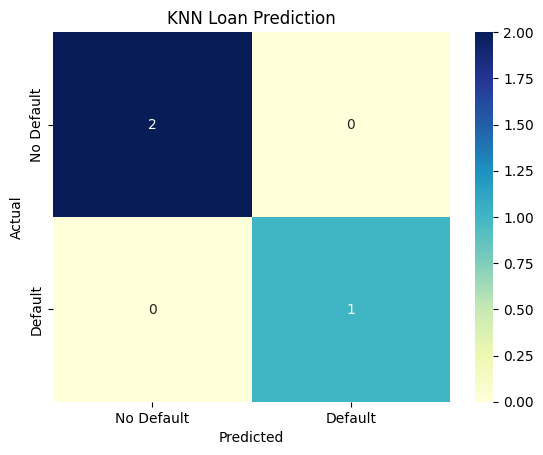

In [39]:
#Matrix

cm = confusion_matrix(y_test, y_pred)

print("\n Matrix:")
print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Loan Prediction")
plt.show()

In [40]:
#Check new customer

new_customer = pd.DataFrame({
    "Age": [46],
    "AnnualIncome": [13],
    "CreditScore": [650],
    "LoanAmount": [11],
    "LoanTerm": [12],
    "EmploymentType": ["Self-Employed"]
})

prediction = knn_model.predict(new_customer)
probability = knn_model.predict_proba(new_customer)

print("\nNew Customer Prediction:")

if prediction[0] == 1:
    print("Customer is likely to default.")
else:
    print("Customer is unlikely to default.")

print("Probability of No Default:", probability[0][0])
print("Probability of Default:", probability[0][1])


New Customer Prediction:
Customer is likely to default.
Probability of No Default: 0.0
Probability of Default: 1.0
